# Verify polytope functions: C++ (Microstructure/Sample_Pn_UU) vs. pure Python (calculate_polytopes_python)

Runs both implementations on the same 2D binary image and plots the resulting `p3h`, `p3v`, `p4`, `p6`, and `L` curves on top of each other for a visual sanity check, alongside the numeric max-diff table.

**Requirements to run the C++ side:**
- `cpp_poly/512/Cpp_source/Polytope/Sample_Pn_UU` must be a working, statically-linked build (see `compare_polytopes.py` at the repo root for background - the original dynamically-linked build needs MinGW runtime DLLs that may not be on PATH).
- Run this notebook with a kernel from the `gui_micro` conda env (needs `numpy`, `numba`, `pandas`, `matplotlib`, `tifffile`; install `ipykernel` in that env if it doesn't show up as a kernel choice: `pip install ipykernel` then select the env's interpreter in VS Code / `python -m ipykernel install --user --name gui_micro`).

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `from src.micro_gui...` resolves the same way calculate_SMD.py does

import numpy as np
import matplotlib.pyplot as plt
import tifffile

from src.micro_gui.analysis.smds import calculate_polytopes, calculate_polytopes_python

## Load the test image

Image shape: (512, 512), foreground (pore) fraction: 0.2504


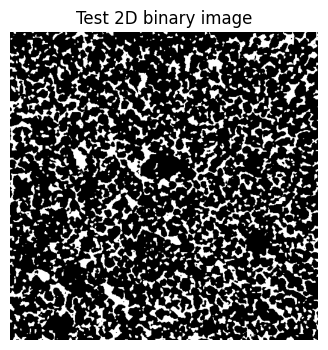

In [2]:
IMAGE_PATH = "../test_images/XCT_11.4um_binary0000.tif"

img = tifffile.imread(IMAGE_PATH).astype(np.uint8)
print(f"Image shape: {img.shape}, foreground (pore) fraction: {img.mean():.4f}")

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Test 2D binary image")
plt.axis("off")
plt.show()

## Run the old C++-based method (`calculate_polytopes`)

This is the same function `calculate_SMD.py` uses - it writes `Mconfig.txt`, shells out to the compiled `Sample_Pn_UU` executable, and reads back the `Sobj*.txt`/`sobj*.txt` outputs.

In [3]:
POLYTOPES = ["p3h", "p3v", "p4", "p6", "L"]

par = {"name": "polytopes", "begx": 0, "begy": 0, "nsamp": img.shape[0], "edge_buffer": 0}

cpathPn = "../cpp_poly/512/Cpp_source/Polytope/"
runtimePn = "../cpp_poly/512/runtime/"
outputPn = "../cpp_poly/512/runtime/output/"

In [4]:
cpp_raw = {}
cpp_scaled = {}

for name in POLYTOPES:
    try:
        raw, scaled = calculate_polytopes(img, par, outputPn, cpathPn, runtimePn, polytope=name)
        cpp_raw[name] = raw
        cpp_scaled[name] = scaled
        print(f"{name}: cpp done")
    except Exception as e:
        print(f"{name}: CPP FAILED - {type(e).__name__}: {e}")

p3h: cpp done
p3v: cpp done
p4: cpp done
p6: cpp done
L: cpp done


## Run the new pure-Python/numba method (`calculate_polytopes_python`)

One call computes everything requested directly on the numpy array - no Mconfig.txt, no subprocess, no compiled executable.

In [5]:
py_raw, py_scaled = calculate_polytopes_python(img, polytopes=tuple(POLYTOPES))
print("python done:", list(py_raw.keys()))

python done: ['p3h', 'p3v', 'p4', 'p6', 'L']


## Numeric comparison table (raw Pn(r) curves)

In [6]:
print(f"{'polytope':10s} {'max_abs_diff':>14s} {'max_rel_diff':>14s} {'n_mismatch(>1e-4)':>20s}")
for name in POLYTOPES:
    if name not in cpp_raw:
        print(f"{name:10s}  (skipped - cpp run failed above)")
        continue
    ref = cpp_raw[name][:, 1]
    mine = py_raw[name][:, 1]
    diff = np.abs(mine - ref)
    rel = diff / np.maximum(np.abs(ref), 1e-12)
    n_mismatch = int(np.sum(diff > 1e-4))
    print(f"{name:10s} {diff.max():14.8f} {rel.max():14.8f} {n_mismatch:20d}")

polytope     max_abs_diff   max_rel_diff    n_mismatch(>1e-4)
p3h            0.00007551     0.00396041                    0
p3v            0.00009094     0.00581134                    0
p4             0.00005696     0.00785702                    0
p6             0.00003043     0.03342919                    0
L              0.00000050     0.05004009                    0


## Plot: raw Pn(r) curves, C++ vs. Python overlaid

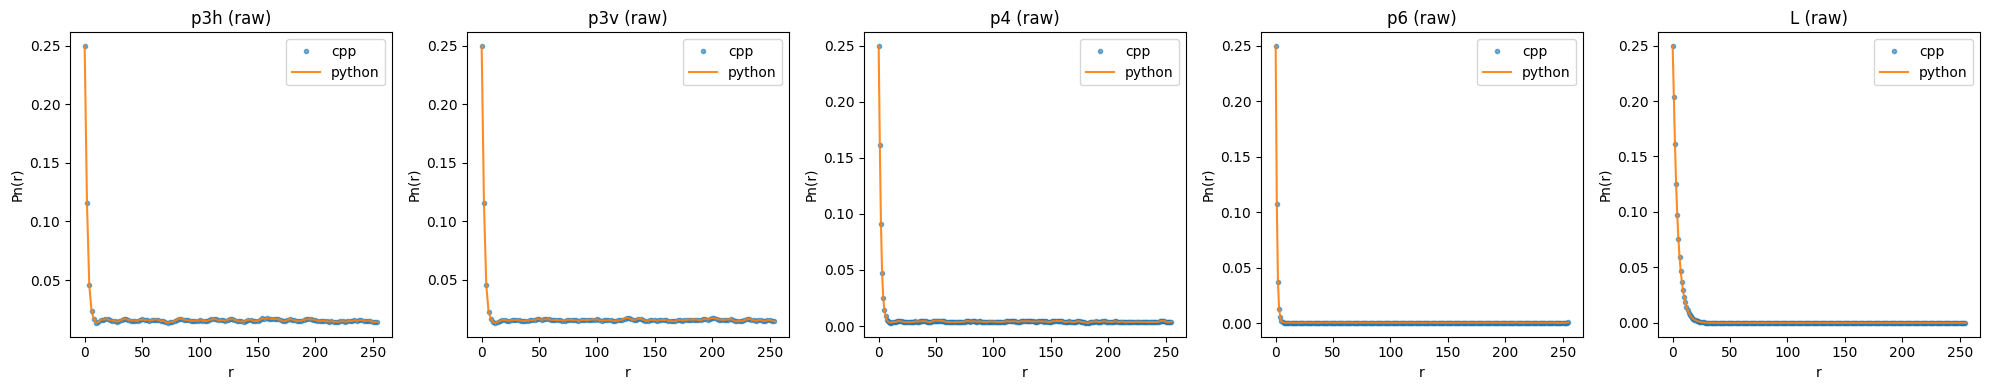

In [7]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 4), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name in cpp_raw:
        if name in ["p3h", "p3v"]:
            ax.plot(cpp_raw[name][::2, 0], cpp_raw[name][::2, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_raw[name][::2, 0], py_raw[name][::2, 1], "-", lw=1.5, alpha=0.9, label="python")
        else:
            ax.plot(cpp_raw[name][:, 0], cpp_raw[name][:, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_raw[name][:, 0], py_raw[name][:, 1], "-", lw=1.5, alpha=0.9, label="python")
    ax.set_title(f"{name} (raw)")
    ax.set_xlabel("r")
    ax.set_ylabel("Pn(r)")
    ax.legend()

plt.tight_layout()
plt.show()

## Plot: scaled fn(r) curves, C++ vs. Python overlaid

(`fn` is the normalised companion curve - `polyfn_*` for P3H/P3V/P4/P6, and the S2-based `scal_autocov` for `L`, matching the original `Microstructure` class.)

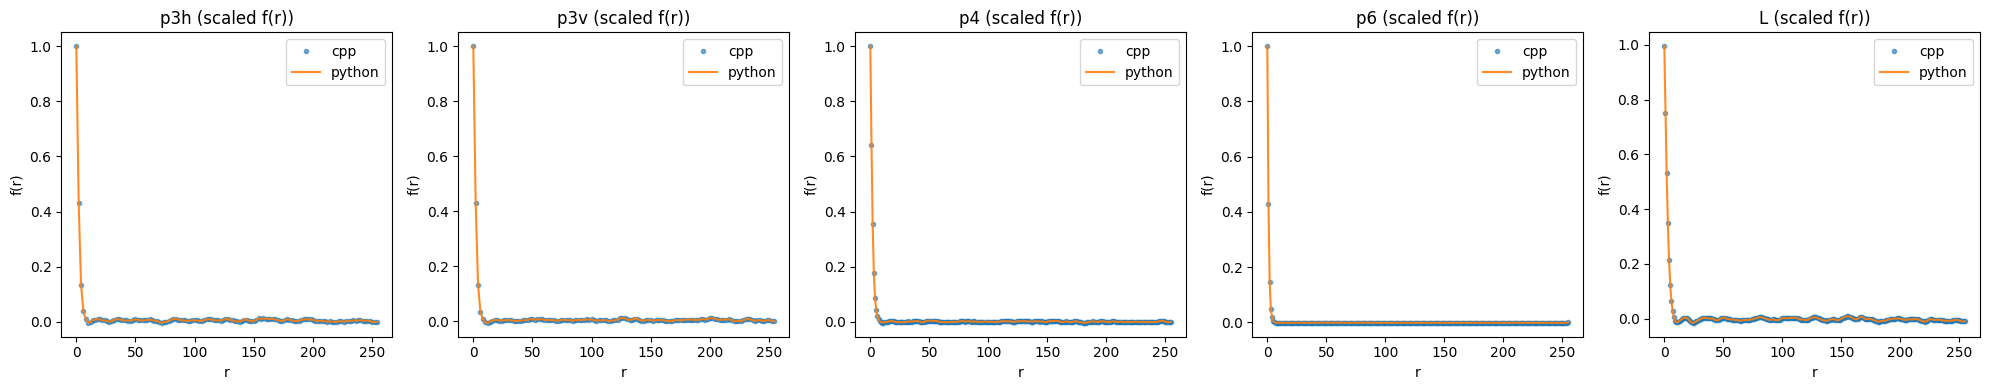

In [8]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 4), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name in cpp_scaled:
        if name in ["p3h", "p3v"]:
            ax.plot(cpp_scaled[name][::2, 0], cpp_scaled[name][::2, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_scaled[name][::2, 0], py_scaled[name][::2, 1], "-", lw=1.5, alpha=0.9, label="python")
        else:
            ax.plot(cpp_scaled[name][:, 0], cpp_scaled[name][:, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_scaled[name][:, 0], py_scaled[name][:, 1], "-", lw=1.5, alpha=0.9, label="python")
    ax.set_title(f"{name} (scaled f(r))")
    ax.set_xlabel("r")
    ax.set_ylabel("f(r)")
    ax.legend()

plt.tight_layout()
plt.show()

## Plot: difference (python - cpp) vs. r, raw curves

A closer look at how small the disagreement actually is (should hover near zero everywhere).

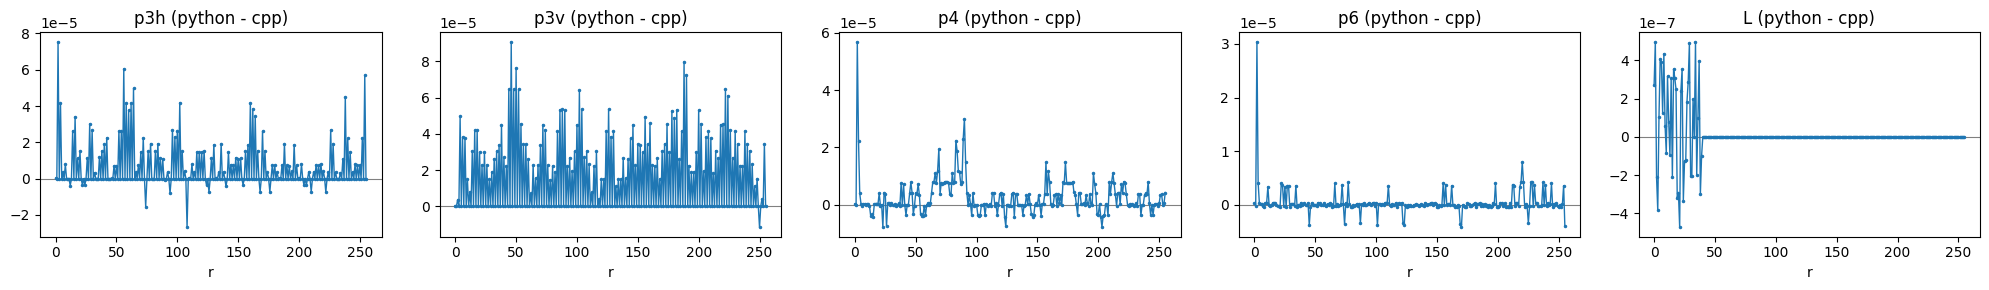

In [9]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 3), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name not in cpp_raw:
        continue
    r = py_raw[name][:, 0]
    diff = py_raw[name][:, 1] - cpp_raw[name][:, 1]
    ax.axhline(0, color="gray", lw=0.8)
    ax.plot(r, diff, ".-", ms=3, lw=1)
    ax.set_title(f"{name} (python - cpp)")
    ax.set_xlabel("r")

plt.tight_layout()
plt.show()

# Verify the two-point cluster function C2 (no GooseEYE)

There's no C++/GooseEYE reference to compare against here (GooseEYE isn't installed - it's not even on PyPI, conda-forge only). So instead of a side-by-side diff like above, this section uses:

1. **Self-consistency checks** on the real test image (things that must be true regardless of what a reference implementation would say, e.g. `C2(0)` must equal the porosity).
2. **A visual check** of the cluster label map itself.
3. **Synthetic images with an exact, hand-computable expected answer** - these are stronger than eyeballing a real image, because we know precisely what the correct output is, not just what looks plausible.

If you later get GooseEYE running (e.g. via conda) somewhere, the natural next step is to add a real `GooseEYE.clusters()`/`GooseEYE.C2()` comparison cell here, the same way the C++ comparison works above.

In [ ]:
from src.micro_gui.analysis.smds import (
    calculate_c2,
    _label_clusters_periodic,
    calculate_s2_periodic,
    scale_c2_by_connectedness,
)

## Check 1: run C2 on the real test image, `C2(0)` must equal the porosity

In [11]:
c2 = calculate_c2(img)
porosity = img.mean()

print(f"C2(0)     = {c2[0]:.6f}")
print(f"porosity  = {porosity:.6f}")
assert np.isclose(c2[0], porosity), "C2(0) must equal the porosity - every foreground pixel is trivially in the same cluster as itself"
print("Check 1 PASSED")

C2(0)     = 0.250420
porosity  = 0.250420
Check 1 PASSED


## Check 2: C2(r) must never exceed S2(r)

"Same cluster" is a strictly stronger condition than "same phase" (every pair in the same cluster is also in the same phase, but not vice versa), so `C2(r) <= S2(r)` must hold at every `r`. If this were ever violated, that would mean the code found *more* same-cluster pairs than same-phase pairs, which is impossible - a solid correctness guardrail.

In [ ]:
s2_same_conv = calculate_s2_periodic(img)

violations = np.sum(c2 > s2_same_conv + 1e-9)
print(f"max(C2 - S2) = {np.max(c2 - s2_same_conv):.10f} (must be <= 0)")
print(f"violations   = {violations} (must be 0)")
assert violations == 0
print("Check 2 PASSED")

plt.figure(figsize=(6, 4))
plt.plot(s2_same_conv, label="S2 (same phase)")
plt.plot(c2, label="C2 (same cluster)")
plt.xlabel("r")
plt.ylabel("probability")
plt.title("C2 vs S2 on the real test image")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Check 3: visualize the cluster label map

A purely visual sanity check - each connected pore should get one solid color, matching the white regions in the original binary image, with no obviously wrong behavior (e.g. everything as one color, or a random speckle with no relation to the real pore shapes). Label IDs are randomly shuffled before plotting so that spatially close clusters (which tend to have close IDs, since flood fill visits the image roughly top-to-bottom) don't end up as similar colors.

n_clusters found in the real image: 893


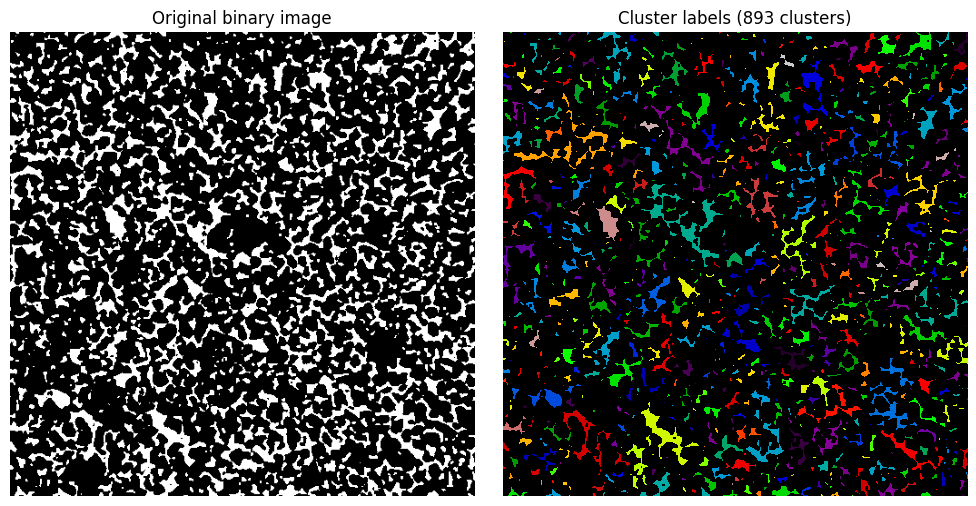

In [13]:
labels = _label_clusters_periodic(img)
n_clusters = int(labels.max())
print(f"n_clusters found in the real image: {n_clusters}")

rng = np.random.RandomState(0)
shuffled_ids = rng.permutation(n_clusters) + 1  # keep 0 (background) fixed, shuffle 1..n
remap = np.zeros(n_clusters + 1, dtype=np.int64)
remap[1:] = shuffled_ids
display_labels = remap[labels]

display_labels_masked = np.ma.masked_where(display_labels == 0, display_labels)
cmap = plt.cm.nipy_spectral.copy()
cmap.set_bad(color="black")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original binary image")
axes[0].axis("off")
axes[1].imshow(display_labels_masked, cmap=cmap)
axes[1].set_title(f"Cluster labels ({n_clusters} clusters)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Check 4: synthetic images with an exact expected answer

Each of these has a hand-computable correct result, so these are closer to unit tests than to visual sanity checks.

In [ ]:
# Test 1: a single filled blob, away from the edges. With only one cluster, "same cluster"
# and "same phase" are identical conditions for every foreground pixel, so C2 must equal
# the (same-convention) periodic S2 EXACTLY - not just approximately.
synthetic1 = np.zeros((64, 64), dtype=np.uint8)
synthetic1[10:30, 10:30] = 1

n_clusters1 = int(_label_clusters_periodic(synthetic1).max())
c2_1 = calculate_c2(synthetic1)
s2_1 = calculate_s2_periodic(synthetic1)

print(f"Test 1 (single blob): n_clusters = {n_clusters1} (expected 1)")
print(f"Test 1 (single blob): max|C2 - S2| = {np.max(np.abs(c2_1 - s2_1)):.10f} (expected 0)")
assert n_clusters1 == 1
assert np.allclose(c2_1, s2_1, atol=1e-9)
print("Test 1 PASSED\n")


# Test 2: fully foreground image. Periodic + 4-connected means every pixel connects to
# every other pixel through the wraparound, so this must be exactly ONE cluster, and every
# pair of points (all of them foreground) is in that cluster, so C2(r) must be 1.0 everywhere.
synthetic2 = np.ones((64, 64), dtype=np.uint8)
n_clusters2 = int(_label_clusters_periodic(synthetic2).max())
c2_2 = calculate_c2(synthetic2)

print(f"Test 2 (fully foreground): n_clusters = {n_clusters2} (expected 1)")
print(f"Test 2 (fully foreground): C2 range = [{c2_2.min():.6f}, {c2_2.max():.6f}] (expected [1.0, 1.0])")
assert n_clusters2 == 1
assert np.allclose(c2_2, 1.0)
print("Test 2 PASSED\n")


# Test 3: fully background image. No foreground pixels at all, so there are no clusters and
# no same-cluster pairs - C2(r) must be exactly 0.0 everywhere.
synthetic3 = np.zeros((64, 64), dtype=np.uint8)
n_clusters3 = int(_label_clusters_periodic(synthetic3).max())
c2_3 = calculate_c2(synthetic3)

print(f"Test 3 (fully background): n_clusters = {n_clusters3} (expected 0)")
print(f"Test 3 (fully background): C2 range = [{c2_3.min():.6f}, {c2_3.max():.6f}] (expected [0.0, 0.0])")
assert n_clusters3 == 0
assert np.allclose(c2_3, 0.0)
print("Test 3 PASSED\n")


# Test 4: this is the important one for periodicity specifically. Two single-pixel-wide
# foreground columns, at column 0 and at the LAST column, with nothing connecting them
# through the interior. They are only adjacent to each other THROUGH the periodic wrap.
# If periodic boundaries were implemented correctly, this must be exactly ONE cluster. If
# periodicity were broken (e.g. accidentally non-periodic), this would show up as 2 clusters.
synthetic4 = np.zeros((64, 64), dtype=np.uint8)
synthetic4[:, 0] = 1
synthetic4[:, -1] = 1
n_clusters4 = int(_label_clusters_periodic(synthetic4).max())

print(f"Test 4 (periodic-wrap merge): n_clusters = {n_clusters4} (expected 1 - only merges if wraparound works)")
assert n_clusters4 == 1
print("Test 4 PASSED\n")


# Test 5: two blobs, far apart and far from the edges (no periodicity involved at all).
# This checks the flip side of Test 4 - that unrelated clusters are correctly kept SEPARATE,
# not spuriously merged.
synthetic5 = np.zeros((64, 64), dtype=np.uint8)
synthetic5[5:15, 5:15] = 1
synthetic5[40:50, 40:50] = 1
n_clusters5 = int(_label_clusters_periodic(synthetic5).max())

print(f"Test 5 (two separate blobs): n_clusters = {n_clusters5} (expected 2)")
assert n_clusters5 == 2
print("Test 5 PASSED")

## Plot: C2 raw and scaled, on the real test image

In [ ]:
c2_raw_2col = np.column_stack((np.arange(len(c2), dtype=np.float64), c2))
c2_scaled = scale_c2_by_connectedness(c2, s2_same_conv)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(c2_raw_2col[:, 0], c2_raw_2col[:, 1], lw=1.5)
axes[0].set_title("C2 (raw)")
axes[0].set_xlabel("r")
axes[0].set_ylabel("C2(r)")
axes[0].grid(alpha=0.3)

axes[1].plot(c2_raw_2col[:, 0], c2_scaled, lw=1.5, color="tab:orange")
axes[1].set_title("C2 (scaled, via scale_c2_by_connectedness = C2/S2)")
axes[1].set_xlabel("r")
axes[1].set_ylabel("g(r)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()